# Forward Selection

In [6]:
import sys
from pathlib import Path

def _find_project_root():
    cwd = Path.cwd()
    if (cwd / "data_manipulation").is_dir():
        return cwd
    if (cwd.parent / "data_manipulation").is_dir():
        return cwd.parent
    return cwd  # fallback

project_root = _find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [7]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from functools import partial

from data_manipulation.data_split import create_dataloader, DemandDataset
from data_manipulation.data_creation import create_data
from model.functions import pinball_loss, rmse, train, get_test_loss

In [8]:
class simple_net(nn.Module):
    def __init__(self,input_size, hidden_size=10, output_size=1):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [9]:
all_specs = [
    "one_hot_month",
    "one_hot_week",
    "one_hot_day_of_week",
    "one_hot_weekend",
    "circular_sin_cos_month",
    "circular_sin_cos_week",
    "circular_sin_cos_day_of_week",
    "7_day_rolling_mean",
    "30_day_rolling_mean",
    "90_day_rolling_mean",
    "180_day_rolling_mean",
    "365_day_rolling_mean",
    "7_day_rolling_volatility",
    "30_day_rolling_volatility",
    "90_day_rolling_volatility",
    "180_day_rolling_volatility",
    "365_day_rolling_volatility",
    "7_day_rolling_min",
    "30_day_rolling_min",
    "90_day_rolling_min",
    "180_day_rolling_min",
    "365_day_rolling_min",
    "7_day_rolling_ema",
    "30_day_rolling_ema",
    "90_day_rolling_ema",
    "180_day_rolling_ema",
    "365_day_rolling_ema",
    "1_day_lag",
    "2_day_lag",
    "3_day_lag",
    "4_day_lag",
    "5_day_lag",
    "6_day_lag",
    "7_day_lag",
    "14_day_lag",
    "28_day_lag",
    "365_day_lag",
    "diff_1_day",
    "diff_7_day",
    "diff_30_day",
    "diff_90_day",
    "diff_180_day",
    "diff_365_day"
]

In [10]:
# Parameters
h_cost = 1
l_cost = 3
epochs = 300

# Init
all_losses_save = []
all_specs_save = []
for i in range(len(all_specs)):
    print(f"Iteration {i}")

    # Initialize variables
    best_loss = float("inf")
    best_spec = None

    for spec in all_specs:

        # Get data for spec
        train_loader, val_loader, test_loader = create_dataloader(
            batch_size=32, 
            test_batch_size=32,
            pin_memory=False,
            data_mask=[
                ("store", 1),
                ("item", 1)
            ],
            specs=[spec] + all_specs,
            )
        
        # Create model
        net = simple_net(train_loader.dataset.x.shape[1])
        loss = partial(pinball_loss, h_cost=h_cost, l_cost=l_cost)
        optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

        # Train model
        _, _ = train(net, optimizer, loss, train_loader, val_loader, epochs=epochs, eval_interval=None, device="cpu", tqdm=False)

        # Get test loss
        test_loss = get_test_loss(net, test_loader, loss, "cpu")

        # See how well it perfromed
        curr_loss = torch.tensor(test_loss).mean()

        # Save the best model
        if curr_loss < best_loss:
            best_loss = curr_loss
            best_spec = spec

    
    # Save the best spec
    all_specs_save.append(best_spec)
    all_losses_save.append(best_loss)
    print(f"Best spec: {best_spec} with loss {best_loss}")

    # Remove the best spec from all_specs
    all_specs.remove(best_spec)


Iteration 0
Best spec: 6_day_lag with loss 2.090758800506592
Iteration 1
Best spec: 180_day_rolling_mean with loss 2.0584073066711426
Iteration 2
Best spec: 90_day_rolling_volatility with loss 2.1588189601898193
Iteration 3
Best spec: 90_day_rolling_ema with loss 2.0852770805358887
Iteration 4
Best spec: diff_30_day with loss 2.0904064178466797
Iteration 5
Best spec: 7_day_rolling_mean with loss 2.160015344619751
Iteration 6
Best spec: 3_day_lag with loss 2.252568483352661
Iteration 7
Best spec: circular_sin_cos_day_of_week with loss 2.211792469024658
Iteration 8
Best spec: 180_day_rolling_min with loss 2.3558084964752197
Iteration 9
Best spec: diff_365_day with loss 2.2025420665740967
Iteration 10
Best spec: one_hot_month with loss 2.6093976497650146
Iteration 11
Best spec: 30_day_rolling_mean with loss 2.4368484020233154
Iteration 12
Best spec: circular_sin_cos_week with loss 2.5866541862487793
Iteration 13
Best spec: 5_day_lag with loss 2.7602174282073975
Iteration 14
Best spec: 180

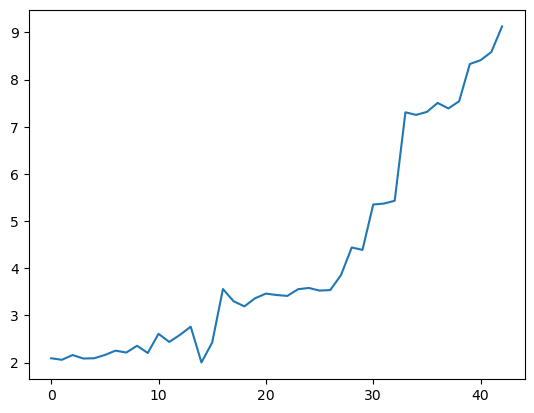

In [12]:
# Plot the data
plt.plot(all_losses_save)

In [14]:
for i in range(len(all_specs_save)):
    print(f"Spec: {all_specs_save[i]}, Loss: {all_losses_save[i]}")

Spec: 6_day_lag, Loss: 2.090758800506592
Spec: 180_day_rolling_mean, Loss: 2.0584073066711426
Spec: 90_day_rolling_volatility, Loss: 2.1588189601898193
Spec: 90_day_rolling_ema, Loss: 2.0852770805358887
Spec: diff_30_day, Loss: 2.0904064178466797
Spec: 7_day_rolling_mean, Loss: 2.160015344619751
Spec: 3_day_lag, Loss: 2.252568483352661
Spec: circular_sin_cos_day_of_week, Loss: 2.211792469024658
Spec: 180_day_rolling_min, Loss: 2.3558084964752197
Spec: diff_365_day, Loss: 2.2025420665740967
Spec: one_hot_month, Loss: 2.6093976497650146
Spec: 30_day_rolling_mean, Loss: 2.4368484020233154
Spec: circular_sin_cos_week, Loss: 2.5866541862487793
Spec: 5_day_lag, Loss: 2.7602174282073975
Spec: 180_day_rolling_ema, Loss: 2.001385450363159
Spec: diff_7_day, Loss: 2.4240691661834717
Spec: one_hot_weekend, Loss: 3.558875799179077
Spec: 30_day_rolling_min, Loss: 3.298921585083008
Spec: 7_day_rolling_min, Loss: 3.1913599967956543
Spec: one_hot_day_of_week, Loss: 3.36362886428833
Spec: 7_day_rolling_

In [19]:
import numpy as np

min_idx = np.argmin(all_losses_save)
for i in range(min_idx + 1):
    print(f"Spec: {all_specs_save[i]}, Loss: {all_losses_save[i]}")

Spec: 6_day_lag, Loss: 2.090758800506592
Spec: 180_day_rolling_mean, Loss: 2.0584073066711426
Spec: 90_day_rolling_volatility, Loss: 2.1588189601898193
Spec: 90_day_rolling_ema, Loss: 2.0852770805358887
Spec: diff_30_day, Loss: 2.0904064178466797
Spec: 7_day_rolling_mean, Loss: 2.160015344619751
Spec: 3_day_lag, Loss: 2.252568483352661
Spec: circular_sin_cos_day_of_week, Loss: 2.211792469024658
Spec: 180_day_rolling_min, Loss: 2.3558084964752197
Spec: diff_365_day, Loss: 2.2025420665740967
Spec: one_hot_month, Loss: 2.6093976497650146
Spec: 30_day_rolling_mean, Loss: 2.4368484020233154
Spec: circular_sin_cos_week, Loss: 2.5866541862487793
Spec: 5_day_lag, Loss: 2.7602174282073975
Spec: 180_day_rolling_ema, Loss: 2.001385450363159
